In [2]:
import pandas as pd

# Load the dataset. Please replace 'your_food_inspection_data.csv' with the actual path to your data file.
# If your data is in a different format (e.g., Excel, JSON), please let me know.
try:
    df = pd.read_excel('/content/Food_Inspections_20260428.xlsx') # Changed to read_excel and updated file path
    print("Dataset loaded successfully. Here are the first 5 rows:")
    print(df.head())
    print(f"\nDataset has {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print("Error: The file was not found.")
    print("Please upload your dataset to the Colab environment or provide the correct file path.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully. Here are the first 5 rows:
   Inspection ID                           DBA Name  \
0        2635613                         SWEET BEAN   
1        2635531                   FAIRGROUNDS ERIE   
2        2635560                TONY'S FRESH MARKET   
3        2635533                    ANTONIO'S TACOS   
4        2635536  THE GRAND CHILD CARE CENTER, INC.   

                            AKA Name  License #                 Facility Type  \
0                         SWEET BEAN  3073361.0                    Restaurant   
1                   FAIRGROUNDS ERIE  2807588.0                    Restaurant   
2                TONY'S FRESH MARKET  1717867.0                 Grocery Store   
3                    ANTONIO'S TACOS  3021085.0                    Restaurant   
4  THE GRAND CHILD CARE CENTER, INC.  2220002.0  Children's Services Facility   

              Risk                 Address     City State      Zip  \
0  Risk 2 (Medium)       2154 S ARCHER AVE  CHICAGO    I

In [3]:
print("\nDistribution of Inspection Results:")
print(df['Results'].value_counts())
print("\nPercentage of Inspection Results:")
print(df['Results'].value_counts(normalize=True) * 100)


Distribution of Inspection Results:
Results
Pass                    159929
Fail                     59640
Pass w/ Conditions       46065
Out of Business          25518
No Entry                 13717
Not Ready                 4365
Business Not Located        94
Name: count, dtype: int64

Percentage of Inspection Results:
Results
Pass                    51.702077
Fail                    19.280505
Pass w/ Conditions      14.891959
Out of Business          8.249496
No Entry                 4.434451
Not Ready                1.411123
Business Not Located     0.030388
Name: proportion, dtype: float64


### Visualizing Inspection Results Distribution

To better understand the spread of inspection outcomes, let's visualize the percentage of each result category using a bar chart.

/tmp/ipykernel_3932/912356260.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_percentage.index, y=results_percentage.values, palette='viridis')


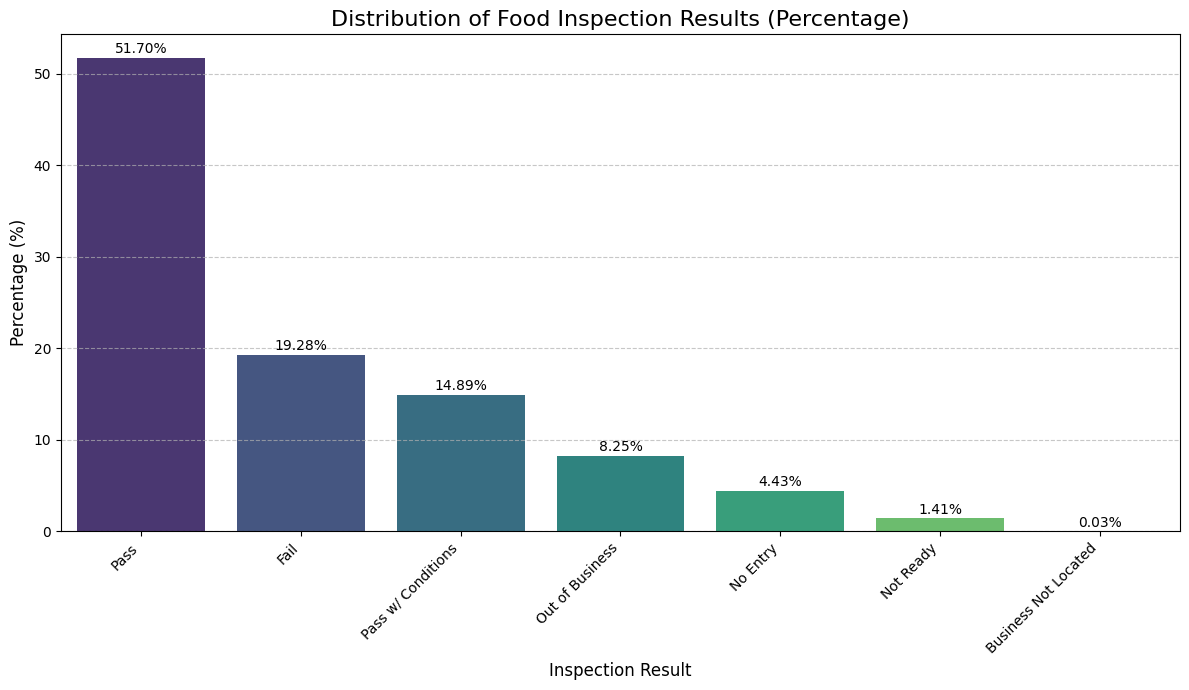

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the percentage of each inspection result
results_percentage = df['Results'].value_counts(normalize=True) * 100

# Create a figure and a set of subplots
plt.figure(figsize=(12, 7))

# Create the bar plot
sns.barplot(x=results_percentage.index, y=results_percentage.values, palette='viridis')

# Add titles and labels
plt.title('Distribution of Food Inspection Results (Percentage)', fontsize=16)
plt.xlabel('Inspection Result', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add percentage values on top of the bars
for index, value in enumerate(results_percentage.values):
    plt.text(index, value + 0.5, f'{value:.2f}%', color='black', ha='center')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Analyzing 'Fail' Rates Over Time

To understand trends in inspection failures, we'll plot the daily 'Fail' rate. This requires converting the 'Inspection Date' column to a proper datetime format and then calculating the proportion of failed inspections each day.

In [5]:
# Convert 'Inspection Date' to datetime objects
df['Inspection Date'] = pd.to_datetime(df['Inspection Date'])

# Calculate daily total inspections and daily failed inspections
daily_inspections = df.groupby('Inspection Date').size().reset_index(name='Total Inspections')
daily_failures = df[df['Results'] == 'Fail'].groupby('Inspection Date').size().reset_index(name='Failed Inspections')

# Merge the two dataframes
daily_results = pd.merge(daily_inspections, daily_failures, on='Inspection Date', how='left').fillna(0)

# Calculate the 'Fail' rate
daily_results['Fail Rate'] = (daily_results['Failed Inspections'] / daily_results['Total Inspections']) * 100

# Display the first few rows of the daily results
print("Daily Inspection Fail Rates:")
display(daily_results.head())


Daily Inspection Fail Rates:


,Inspection Date,Total Inspections,Failed Inspections,Fail Rate
0,2010-01-04,7,2.0,28.571429
1,2010-01-05,71,20.0,28.169014
2,2010-01-06,81,26.0,32.098765
3,2010-01-07,62,18.0,29.032258
4,2010-01-08,43,8.0,18.604651


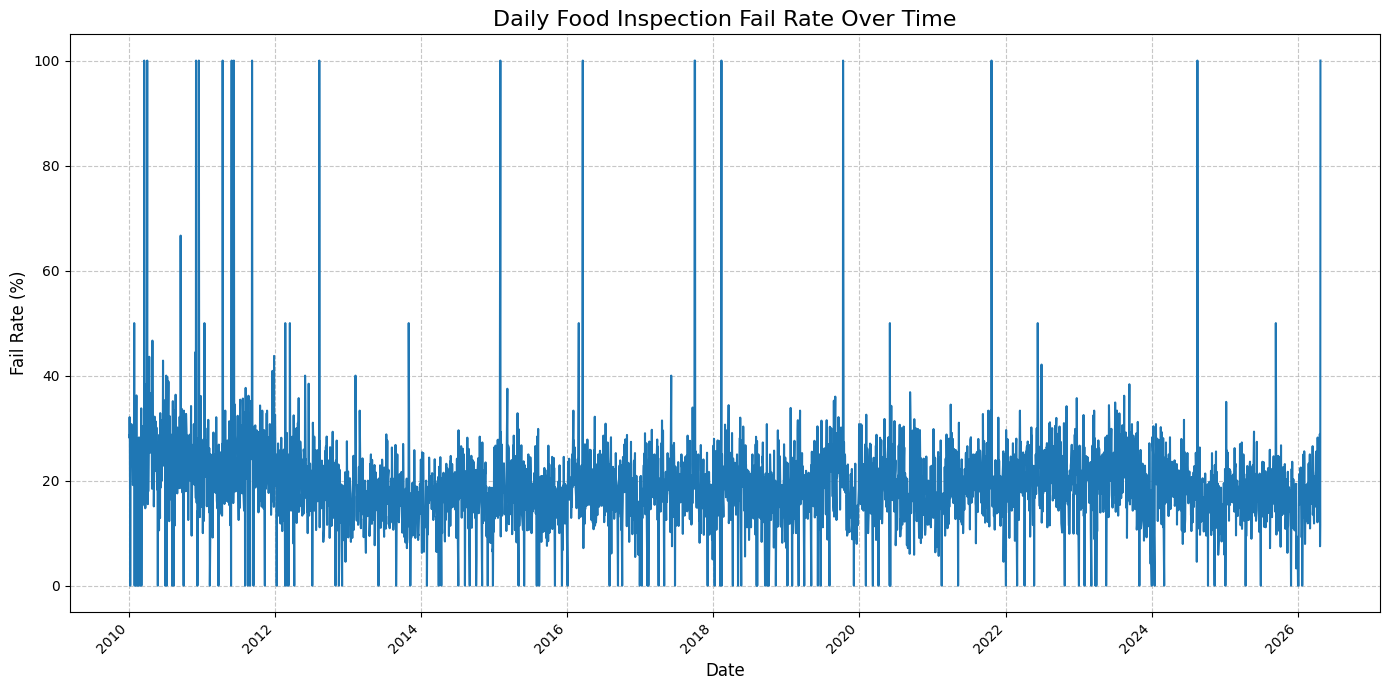

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting the 'Fail' rates over time
plt.figure(figsize=(14, 7))
sns.lineplot(x='Inspection Date', y='Fail Rate', data=daily_results)

plt.title('Daily Food Inspection Fail Rate Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Fail Rate (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Identifying Facility Types with Highest Failure Rates

To understand if certain types of establishments are more prone to inspection failures, we will calculate the 'Fail Rate' for each 'Facility Type'.

In [7]:
# Calculate total inspections per Facility Type
facility_inspections = df.groupby('Facility Type').size().reset_index(name='Total Inspections')

# Calculate failed inspections per Facility Type
facility_failures = df[df['Results'] == 'Fail'].groupby('Facility Type').size().reset_index(name='Failed Inspections')

# Merge the two dataframes
facility_results = pd.merge(facility_inspections, facility_failures, on='Facility Type', how='left').fillna(0)

# Calculate the 'Fail Rate' for each Facility Type
facility_results['Fail Rate'] = (facility_results['Failed Inspections'] / facility_results['Total Inspections']) * 100

# Sort by 'Fail Rate' in descending order to find the highest
highest_fail_rate_facility = facility_results.sort_values(by='Fail Rate', ascending=False)

print("Facility Types with Highest Fail Rates:")
display(highest_fail_rate_facility.head(10))

Facility Types with Highest Fail Rates:


,Facility Type,Total Inspections,Failed Inspections,Fail Rate
432,Social Club,2,2.0,100.0
470,after school program,2,2.0,100.0
19,ART GALLERY,1,1.0,100.0
455,UNLICENSED FACILITY,3,3.0,100.0
261,Illegal Vendor,3,3.0,100.0
80,CHURCH/AFTER SCHOOL PROGRAM,1,1.0,100.0
266,KIDS CAFE,1,1.0,100.0
362,PROTEIN SHAKE BAR,1,1.0,100.0
508,religious,1,1.0,100.0
160,FARMER'S MARKET,1,1.0,100.0


/tmp/ipykernel_3932/1934295219.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fail Rate', y='Facility Type', data=top_10_fail_rate_facilities, palette='Reds_d')


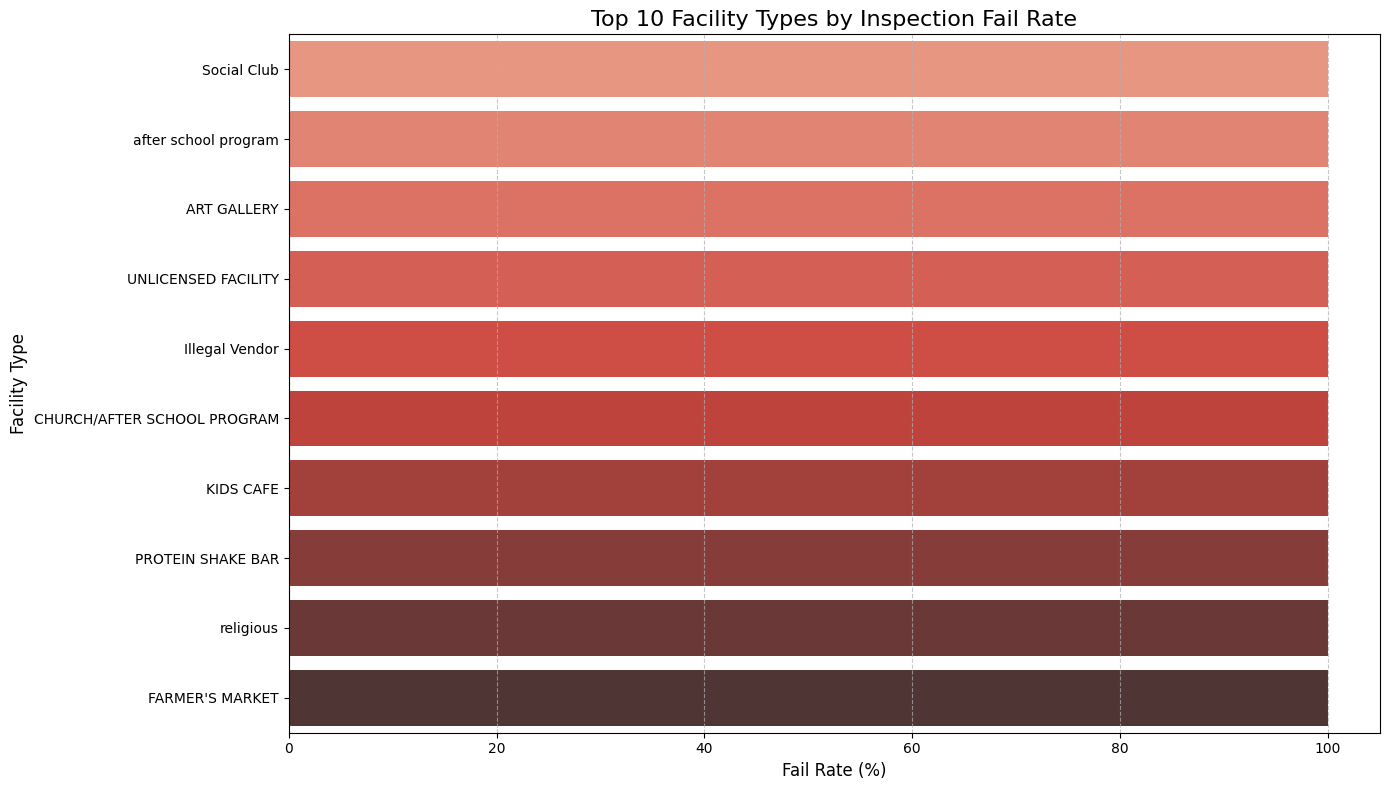

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Take the top 10 facility types by fail rate for visualization
top_10_fail_rate_facilities = highest_fail_rate_facility.head(10)

plt.figure(figsize=(14, 8))
sns.barplot(x='Fail Rate', y='Facility Type', data=top_10_fail_rate_facilities, palette='Reds_d')

plt.title('Top 10 Facility Types by Inspection Fail Rate', fontsize=16)
plt.xlabel('Fail Rate (%)', fontsize=12)
plt.ylabel('Facility Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Comparing Fail Rates by Inspection Type

To see if the type of inspection influences the outcome, we'll calculate the fail rate for each category in the 'Inspection Type' column.

In [9]:
# Calculate total inspections per Inspection Type
type_inspections = df.groupby('Inspection Type').size().reset_index(name='Total Inspections')

# Calculate failed inspections per Inspection Type
type_failures = df[df['Results'] == 'Fail'].groupby('Inspection Type').size().reset_index(name='Failed Inspections')

# Merge and calculate fail rate
type_results = pd.merge(type_inspections, type_failures, on='Inspection Type', how='left').fillna(0)
type_results['Fail Rate'] = (type_results['Failed Inspections'] / type_results['Total Inspections']) * 100

# Sort by fail rate and filter for types with a significant number of inspections (e.g., > 100) for better insight
significant_type_results = type_results[type_results['Total Inspections'] > 100].sort_values(by='Fail Rate', ascending=False)

print("Inspection Types with Highest Fail Rates (Min 100 inspections):")
display(significant_type_results.head(10))

Inspection Types with Highest Fail Rates (Min 100 inspections):


,Inspection Type,Total Inspections,Failed Inspections,Fail Rate
48,License-Task Force,604,366.0,60.596026
94,Task Force Liquor 1475,252,131.0,51.984127
58,Out of Business,284,112.0,39.436620
20,Complaint-Fire,161,59.0,36.645963
18,Complaint,29087,9652.0,33.183209
45,License,41265,12417.0,30.090876
76,Short Form Fire-Complaint,113,32.0,28.318584
80,Suspected Food Poisoning,1000,260.0,26.000000
16,Canvass,160432,29358.0,18.299342
22,Consultation,679,113.0,16.642121


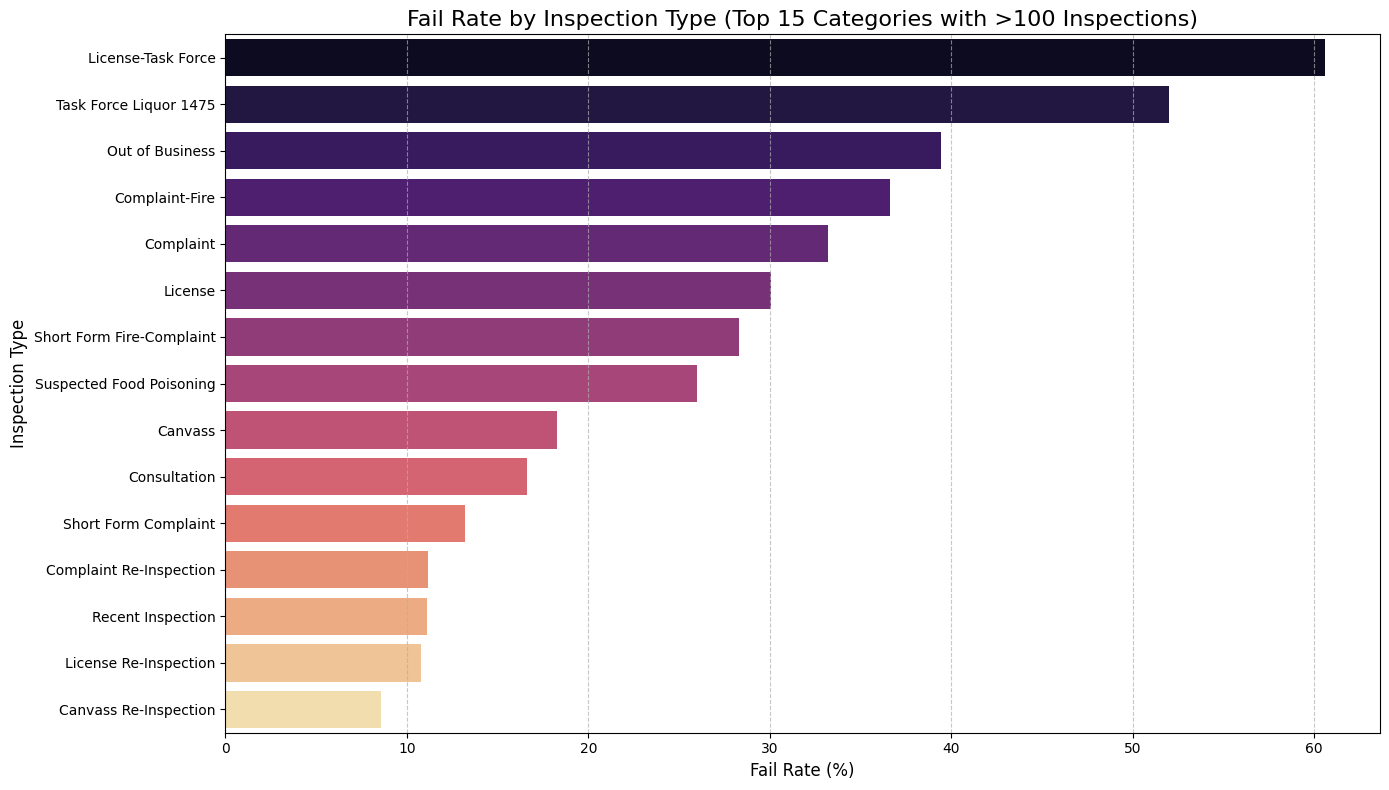

In [10]:
plt.figure(figsize=(14, 8))
sns.barplot(x='Fail Rate', y='Inspection Type', data=significant_type_results.head(15), hue='Inspection Type', palette='magma', legend=False)

plt.title('Fail Rate by Inspection Type (Top 15 Categories with >100 Inspections)', fontsize=16)
plt.xlabel('Fail Rate (%)', fontsize=12)
plt.ylabel('Inspection Type', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Risk-Wise Inspection Analysis

We will now examine how the assigned risk level (Risk 1 High, Risk 2 Medium, Risk 3 Low) correlates with the inspection results.

In [11]:
# Create a cross-tabulation of Risk and Results
risk_results = pd.crosstab(df['Risk'], df['Results'], normalize='index') * 100

print("Percentage of Results for each Risk Category:")
display(risk_results)

Percentage of Results for each Risk Category:


Results,Business Not Located,Fail,No Entry,Not Ready,Out of Business,Pass,Pass w/ Conditions
Risk,,,,,,,
All,1.098901,5.494505,14.285714,64.835165,14.285714,0.000000,0.000000
Risk 1 (High),0.020465,19.153985,5.040385,1.093767,6.120219,53.001110,15.570069
Risk 2 (Medium),0.046933,19.058450,2.960396,1.963970,10.522041,50.545146,14.903065
Risk 3 (Low),0.049817,21.031219,1.980239,2.822982,23.306211,42.299070,8.510462


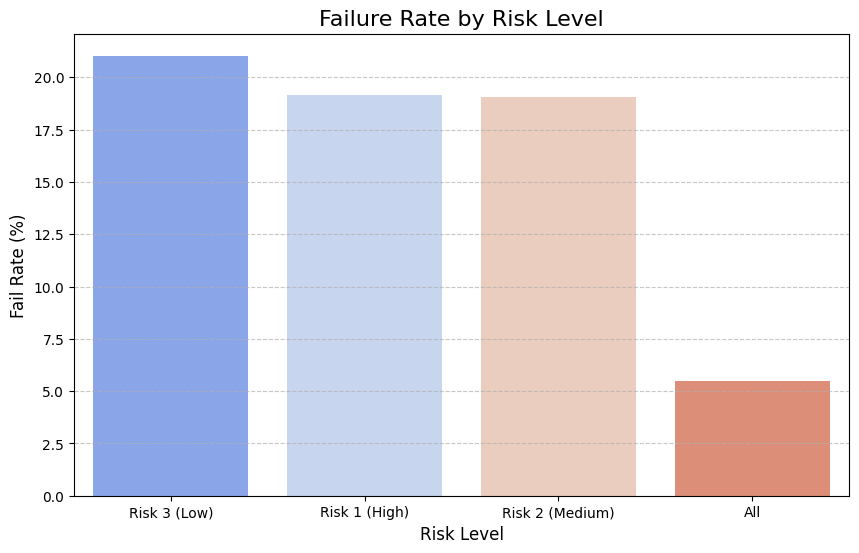

In [12]:
# Plotting the Fail rate specifically across different Risk levels
risk_fail_rate = risk_results['Fail'].sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Risk', y='Fail', data=risk_fail_rate, hue='Risk', palette='coolwarm', legend=False)

plt.title('Failure Rate by Risk Level', fontsize=16)
plt.xlabel('Risk Level', fontsize=12)
plt.ylabel('Fail Rate (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Top 5 Violation Factors Contributing to Failures

To identify specific reasons for failure, we will analyze the `Violations` column for all inspections marked as 'Fail' and extract the most common violation types.

In [13]:
import pandas as pd
import re

# Filter for failed inspections and drop rows with missing violations
failed_df = df[df['Results'] == 'Fail'].dropna(subset=['Violations'])

def extract_violations(violation_text):
    # Violations are typically separated by ' | ' and start with a number and description
    # e.g., '10. ADEQUATE HANDWASHING FACILITIES... | 15. ...'
    parts = violation_text.split('|')
    extracted = []
    for part in parts:
        # Match the standard format: "Number. Description - Comments"
        match = re.search(r'\d+\.\s*([^\-]+)', part)
        if match:
            extracted.append(match.group(1).strip())
    return extracted

# Apply extraction and explode the list into individual rows
all_violations = failed_df['Violations'].apply(extract_violations).explode()

# Count the top 5
top_violations = all_violations.value_counts().head(5).reset_index()
top_violations.columns = ['Violation Description', 'Frequency']

print("Top 5 Factors Contributing to Failures:")
display(top_violations)

Top 5 Factors Contributing to Failures:


,Violation Description,Frequency
0,FOOD AND NON,31464
1,"PHYSICAL FACILITIES INSTALLED, MAINTAINED & CLEAN",26477
2,"FLOORS: CONSTRUCTED PER CODE, CLEANED, GOOD RE...",19371
3,"WALLS, CEILINGS, ATTACHED EQUIPMENT CONSTRUCTE...",18257
4,NO EVIDENCE OF RODENT OR INSECT OUTER OPENINGS...,16432


/tmp/ipykernel_3932/190744170.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Violation Description', data=top_violations, palette='rocket')


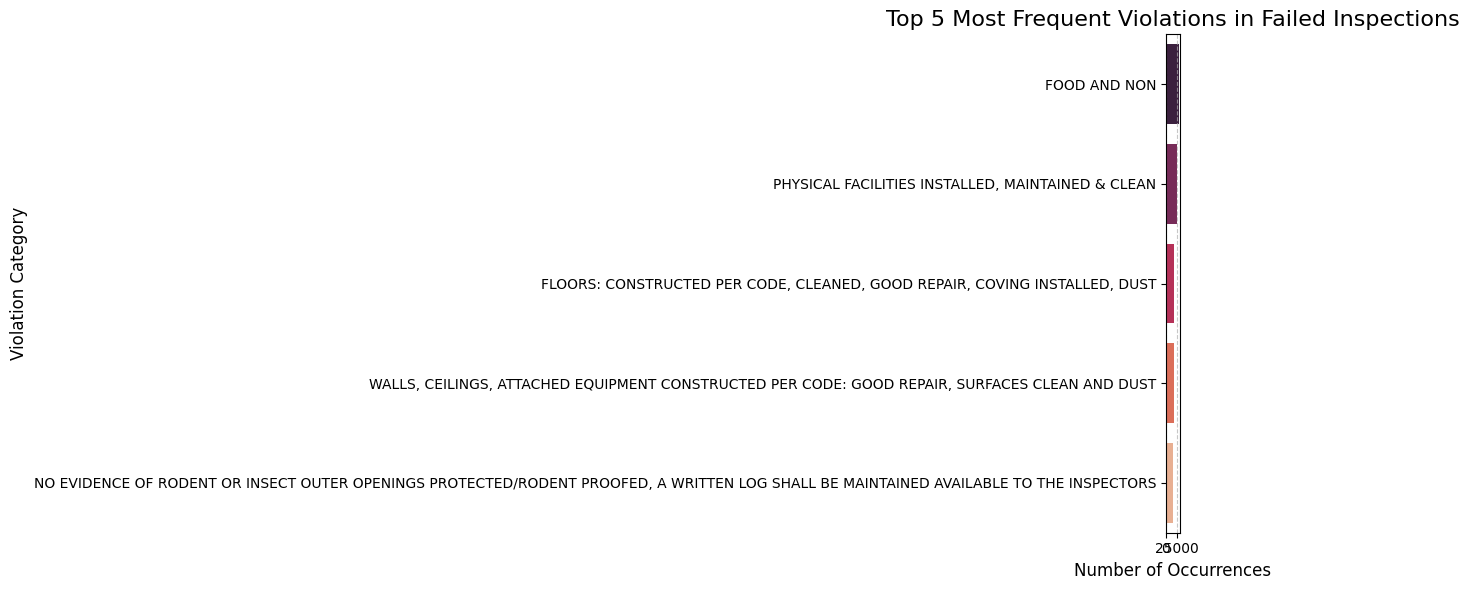

In [14]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Frequency', y='Violation Description', data=top_violations, palette='rocket')
plt.title('Top 5 Most Frequent Violations in Failed Inspections', fontsize=16)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Violation Category', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()